<a href="https://colab.research.google.com/github/nmwiley808/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project/blob/main/notebooks/02_audio_preprocessing_%26_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 - Audio Preprocessing & Feature Extraction

## Description

This notebook implements standgeardized audio preprocessing pipelines for the threee benchmark datasets:

- GTZAN
- MTG-Jamendo
- MagnaTagATune

The preprocessing stage converts raw audio into machine learning ready feature representations including:

- Mel-Spectrograms
- Log-Mel Spectrograms
- MFCCs (Mel-Frequency Cepstral Coefficients)

All audio is standardized to a consistent sampling rate and fixed duration to ensure cross-dataset compatibility. Additionally, preprocessing runtime is benchmarked to evaluate computational feasibility for full-scale model training.

In [1]:
# Mount Drive & Setup Enviroment
from google.colab import drive
drive.mount('/content/drive')

import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import time

PROJECT_PATH = "/content/drive/MyDrive/csci198/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project"
os.chdir(PROJECT_PATH)

print("Working directory: ", os.getcwd())

Mounted at /content/drive
Working directory:  /content/drive/MyDrive/csci198/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project


In [6]:
# Define Standardization Parameters
TARGET_SR = 22050   # standard sample rate
DURATION = 30       # seconds
SAMPLES_PER_TRACK = TARGET_SR * DURATION

N_MELS = 128
N_MFCC = 13

print ("Target SR:", TARGET_SR)
print ("Samples per track:", SAMPLES_PER_TRACK)

Target SR: 22050
Samples per track: 661500


In [7]:
# Safe Audio Loader
def load_audio(file_path, target_sr=TARGET_SR):
    try:
        y, sr = librosa.load(file_path, sr=target_sr)
    except Exception as e:
        print("Error loading file:", e)
        return None

    if y is None or len(y) == 0:
        return None

    # Trim or pad
    if len(y) > SAMPLES_PER_TRACK:
        y = y[:SAMPLES_PER_TRACK]
    else:
        y = np.pad(y, (0, SAMPLES_PER_TRACK - len(y)))

    return y

In [8]:
# Feature Extraction Functions

# Mel Spectrogram
def extract_mel(y):
    return librosa.feature.melspectrogram(
        y=y,
        sr=TARGET_SR,
        n_mels=N_MELS
    )


# Log-Mel Spectrogram
def extract_log_mel(y):
    mel = extract_mel(y)
    return librosa.power_to_db(mel, ref=np.max)

# MFCC
def extract_mfcc(y):
    return librosa.feature.mfcc(
        y=y,
        sr=TARGET_SR,
        n_mfcc=N_MFCC
    )

In [9]:
# Automatically Find Sample File
def find_sample_file(root_folder):
    for root, dirs, files in os.walk(root_folder):
        for file in files:
            if file.endswith(".wav") or file.endswith(".mp3"):
                return os.path.join(root, file)
    return None

In [10]:
# Test GTZAN
gtzan_sample = find_sample_file("data/raw/gtzan")

if gtzan_sample is None:
    raise FileNotFoundError("No GTZAN file found.")

print("Using GTZAN file:", gtzan_sample)

y = load_audio(gtzan_sample)

mel = extract_mel(y)
log_mel = extract_log_mel(y)
mfcc = extract_mfcc(y)

print("Mel shape:", mel.shape)
print("Log-Mel shape:", log_mel.shape)
print("MFCC shape:", mfcc.shape)

Using GTZAN file: data/raw/gtzan/Data/genres_original/blues/blues.00005.wav
Mel shape: (128, 1292)
Log-Mel shape: (128, 1292)
MFCC shape: (13, 1292)


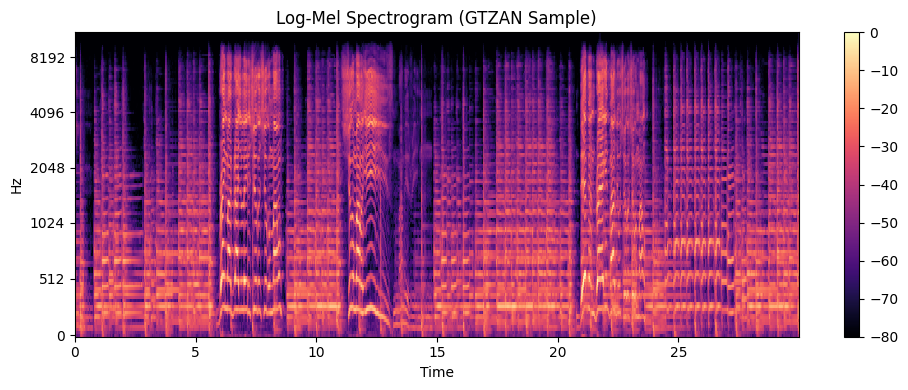

In [12]:
# Visualize Log-Mel
plt.figure(figsize=(10, 4))
librosa.display.specshow(log_mel, sr=TARGET_SR, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title("Log-Mel Spectrogram (GTZAN Sample)")
plt.tight_layout()
plt.show()

In [13]:
# Benchmark Runtime
start = time.time()

for _ in range(10):
  y = load_audio(gtzan_sample)
  _ = extract_mel(y)

end = time.time()

print("Average preprocessing time per track:",
      (end - start) / 10, "seconds")

Average preprocessing time per track: 0.044270563125610354 seconds


In [16]:
# Test Magna Consistency
magna_sample = find_sample_file("data/raw/magnatagatune")

if magna_sample is None:
    raise FileNotFoundError("No Magna file found.")

print("Using Magna file:", magna_sample)

y_magna = load_audio(magna_sample)
log_mel_magna = extract_log_mel(y_magna)

print("Magna Log-Mel shape:", log_mel_magna.shape)

Using Magna file: data/raw/magnatagatune/MagnaTagATune/5/nova_express-gimme_some-02-walk_away-0-29.mp3
Magna Log-Mel shape: (128, 1292)


In [17]:
# Test MTG Consistency (If Audio Exists)
mtg_sample = find_sample_file("data/raw/mtg_jamendo")

if mtg_sample:
  print ("Using MTG file:", mtg_sample)
  y_mtg = load_audio(mtg_sample)
  log_mel_mtg = extract_log_mel(y_mtg)
  print("Log-Mel shape:", log_mel)
else:
  print ("No MTG file found - skipping.")

No MTG file found - skipping.
